# Introduction to Regression with Neural Networks in TensorFlow

There are many definitions for a [regression problem](https://en.wikipedia.org/wiki/Regression_analysis) but in our case, we're going to simplify it to be: predicting a continuous number.

For example, you might want to:
- Predict the selling price of houses given information about them (such as number of rooms, size, number of bathrooms).
- Predict the coordinates of a bounding box of an item in an image.
- Predict the cost of medical insurance for an individual given their demographics (age, sex, gender, race).

We're going to set the foundations for how to take a sample of inputs (this is your data), build a neural network to discover patterns in those inputs and then make a prediction (in the form of a number) based on those inputs.

## What we're going to cover

Specifically, we're going to go through doing the following with TensorFlow:
- Architecture of a regression model
- Input shapes and output shapes
  - `X`: features/data (inputs)
  - `y`: labels (outputs)
- Creating custom data to view and fit
- Steps in modelling
  - Creating a model
  - Compiling a model
    - Defining a loss function
    - Setting up an optimizer
    - Creating evaluation metrics
  - Fitting a model (getting it to find patterns in our data)
- Evaluating a model
  - Visualizng the model
  - Looking at training curves
  - Compare predictions to ground truth (using our evaluation metrics)
- Saving a model (so we can use it later)
- Loading a model

## Typical architecture of a regresison neural network

Following is a generic setup for ingesting a collection of numbers, finding patterns in them and then outputing some kind of target number.


| **Hyperparameter** | **Typical value** |
| --- | --- |
| Input layer shape | Same shape as number of features (e.g. 3 for # bedrooms, # bathrooms, # car spaces in housing price prediction) |
| Hidden layer(s) | Problem specific, minimum = 1, maximum = unlimited |
| Neurons per hidden layer | Problem specific, generally 10 to 100 |
| Output layer shape | Same shape as desired prediction shape (e.g. 1 for house price) |
| Hidden activation | Usually [ReLU](https://www.kaggle.com/dansbecker/rectified-linear-units-relu-in-deep-learning) (rectified linear unit) |
| Output activation | None, ReLU, logistic/tanh |
| Loss function | [MSE](https://en.wikipedia.org/wiki/Mean_squared_error) (mean square error) or [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) (mean absolute error)/Huber (combination of MAE/MSE) if outliers |
| Optimizer | [SGD](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD) (stochastic gradient descent), [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) |



> 🔑 **Note:** A **hyperparameter** in machine learning is something a data analyst or developer can set themselves, where as a **parameter** usually describes something a model learns on its own (a value not explicitly set by an analyst).

In [1]:
# importing Necessary Libraries:
import os
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # '2' means "Show me Errors only, hide Info and Warnings"
warnings.filterwarnings('ignore') # Hide the "FutureWarning" (Python logs)

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
# Creating Random Linear Data:

# Features / Independent Variables:
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Label / Target / Dependent Variable:
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

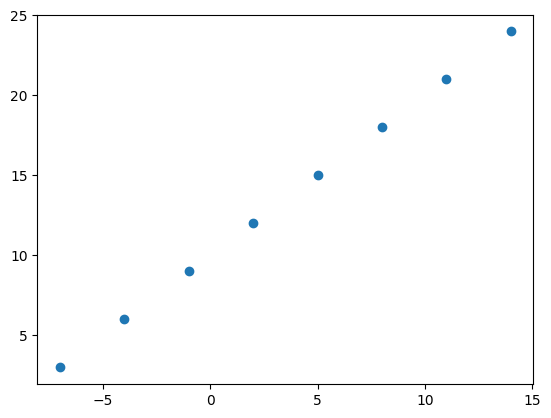

In [3]:
# Visualizing Data:

plt.scatter(X, y)
plt.show()

#### Input shapes and output shapes

One of the most important concepts when working with neural networks are the input and output shapes.

The **input shape** is the shape of your data that goes into the model.

The **output shape** is the shape of your data you want to come out of your model.

These will differ depending on the problem you're working on.

Neural networks accept numbers and output numbers. These numbers are typically represented as tensors (or arrays).

Before, we created data using NumPy arrays, but we could do the same with tensors.

In [4]:
X = tf.constant(X)
y = tf.constant(y)

I0000 00:00:1767621008.968703   73971 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [5]:
X, y

(<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

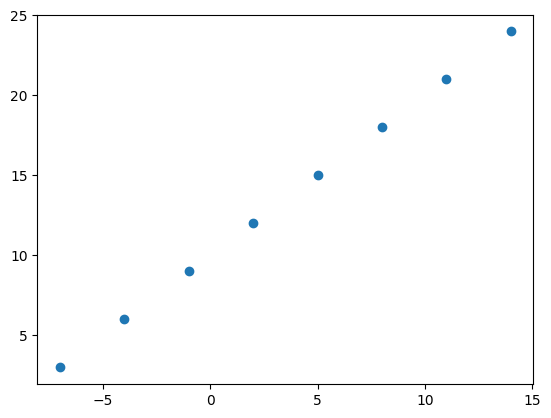

In [6]:
plt.scatter(X, y)
plt.show()

Our goal here will be to use `X` to predict `y`.

So our **input** will be `X` and our **output** will be `y`.

Knowing this, what do you think our input and output shapes will be?

In [7]:
input_shape = X[0].shape
output_shape = y[0].shape

print(input_shape, output_shape)

() ()


From this it seems our inputs and outputs have no shape?

How could that be?

It's because no matter what kind of data we pass to our model, it's always going to take as input and return as ouput some kind of tensor.

But in our case because of our dataset (only 2 small lists of numbers), we're looking at a special kind of tensor, more specificially a rank 0 tensor or a scalar.

In [8]:
X[0], y[0]

(<tf.Tensor: shape=(), dtype=float64, numpy=-7.0>,
 <tf.Tensor: shape=(), dtype=float64, numpy=3.0>)

In our case, we're trying to build a model to predict the pattern between `X[0]` equalling `-7.0` and `y[0]` equalling `3.0`.

So now we get our answer, we're trying to use 1 `X` value to predict 1 `y` value.

The concepts of input and output shapes to a model are fundamental. 

In fact, they're probably two of the things we'll spend the most time on when we work with neural networks: **making sure your input and outputs are in the correct shape**.

![example of input and output shapes for a housing price prediction problem](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/01-input-and-output-shapes-housing-prices.png)
*If you were working on building a machine learning algorithm for predicting housing prices, your inputs may be number of bedrooms, number of bathrooms and number of garages, giving you an input shape of 3 (3 different features). And since you're trying to predict the price of the house, your output shape would be 1.*

In [9]:
X.shape

TensorShape([8])

In [10]:
X

<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>

In [11]:
tf.reshape(X, shape= (8,1))

<tf.Tensor: shape=(8, 1), dtype=float64, numpy=
array([[-7.],
       [-4.],
       [-1.],
       [ 2.],
       [ 5.],
       [ 8.],
       [11.],
       [14.]])>

We will need to reshape X as Models in tensorflow Requires Input Dimension to be Atleast 2.

#### Steps in modelling

Now we know what data we have as well as the input and output shapes, let's see how we'd build a neural network to model it.

In TensorFlow, there are typically 3 fundamental steps to creating and training a model.

1. **Creating a model** - piece together the layers of a neural network yourself (using the [Functional](https://www.tensorflow.org/guide/keras/functional) or [Sequential API](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential)) or import a previously built model (known as transfer learning).
2. **Compiling a model** - defining how a models performance should be measured (loss/metrics) as well as defining how it should improve (optimizer). 
3. **Fitting a model** - letting the model try to find patterns in the data (how does `X` get to `y`). 

Let's see these in action using the [Keras Sequential API](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential) to build a model for our regression data. And then we'll step through each.

In [12]:
from tensorflow.keras import Sequential # To Create Model Using Sequential API
from tensorflow.keras.layers import Dense # To Create Dense Neurons in Network

In [13]:
tf.random.set_seed(42) # To Produce same results every time.

base_model = Sequential() # Creating a Sequential Model

base_model.add(Dense(units= 1)) # Adding One Dense Neuron in Model

# Compiling The Model
base_model.compile(loss= 'mae', # Mean Absolute Error
                  optimizer= 'sgd', # SGD = Stochastic Gradient Descent
                  metrics= ['mae'])

# Fitting The Model with Data
base_model.fit(tf.reshape(X, shape= (8,1)),
               y, 
               epochs= 5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - loss: 10.2338 - mae: 10.2338
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 10.1013 - mae: 10.1013
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 9.9688 - mae: 9.9688
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 9.8363 - mae: 9.8363
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 9.7038 - mae: 9.7038


I0000 00:00:1767621010.035181   74118 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


#### Trying to Predict value of y using our Trained Model:

Keep in mind that Relationship between our Original Data is y = X + 10.

In [14]:
X

<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>

In [15]:
y

<tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>

In [16]:
X + 10

<tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>

In [17]:
# Making a Prediction Using Trained Model:
base_model.predict(tf.constant([[17.0]])) # Because we need to pass tensor to our model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


array([[18.889338]], dtype=float32)

It doesn't go very well... it should've output something close to 27.0.
(y = X + 10) ..> X = 17 ..> y = 27.

> 🤔 **Question:** What's Keras? I thought we were working with TensorFlow but every time we write TensorFlow code, `keras` comes after `tf` (e.g. `tf.keras.layers.Dense()`)?

Before TensorFlow 2.0+, [Keras](https://keras.io/) was an API designed to be able to build deep learning models with ease. Since TensorFlow 2.0+, its functionality has been tightly integrated within the TensorFlow library.

#### Improving a model

To improve our model, we alter almost every part of the 3 steps we went through before.

1. **Creating a model** - here we might want to add more layers, increase the number of hidden units (also called neurons) within each layer, change the activation functions of each layer.
2. **Compiling a model** - you might want to choose optimization function or perhaps change the **learning rate** of the optimization function.
3. **Fitting a model** - perhaps you could fit a model for more **epochs** (leave it training for longer) or on more data (give the model more examples to learn from).

In [18]:
# Creating Improved Model by Increasing the Training Time (Number of Epochs):

tf.random.set_seed(42)

imprvd_model1 = Sequential()

imprvd_model1.add(Dense(units= 1))

imprvd_model1.compile(loss= 'mae',
                     optimizer= 'sgd',
                     metrics= ['mae'])

imprvd_model1.fit(tf.reshape(X, shape= (8,1)),
                 y,
                 epochs= 100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - loss: 11.6777 - mae: 11.6777
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 11.5452 - mae: 11.5452
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 11.4127 - mae: 11.4127
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 11.2802 - mae: 11.2802
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 11.1477 - mae: 11.1477
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 11.0152 - mae: 11.0152
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 10.8827 - mae: 10.8827
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 10.7502 - mae: 10.7502
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 10.6177 - mae: 10.6177
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 10.4852 - mae: 10.4852
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 10.3527 - mae: 10.3527
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 10.2202 - mae: 10.2202
Epoch 13/100
1/1 ━━━━━━━

MAE is down from 9.70 (in Previuos Model) to 6.87.

In [19]:
# Making a Prediction using Improved Model:
imprvd_model1.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


array([[29.916368]], dtype=float32)

Our Prediction Should be 27.

This Model is quite close to getting correct prediction than base model.

`Creating Improved Model by Increasing the Hidden layers, Number of Neurons and Using Activation Functions for layers:`

In [20]:
tf.random.set_seed(42)

imprvd_model2 = Sequential()

imprvd_model2.add(Dense(units= 10, activation= 'relu'))
imprvd_model2.add(Dense(units= 5, activation= 'relu'))
imprvd_model2.add(Dense(units= 1))

imprvd_model2.compile(loss= 'mae',
                     optimizer= 'sgd',
                     metrics= ['mae'])

imprvd_model2.fit(tf.reshape(X, shape= (8,1)),
                 y,
                 epochs= 100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step - loss: 15.4320 - mae: 15.4320
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 15.1337 - mae: 15.1337
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 14.8701 - mae: 14.8701
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 14.6358 - mae: 14.6358
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 14.4424 - mae: 14.4424
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 14.2843 - mae: 14.2843
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 14.1415 - mae: 14.1415
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 14.0143 - mae: 14.0143
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 13.9005 - mae: 13.9005
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 13.7953 - mae: 13.7953
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 13.6998 - mae: 13.6998
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 13.6672 - mae: 13.6672
Epoch 13/100
1/1 ━━━━━━━

In [21]:
# Making a Prediction using Improved Model:
imprvd_model2.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


array([[0.99999934]], dtype=float32)

`Creating Improved Model by Changing the Optimizer and Adjusting Learning Rate:`

In [22]:
tf.random.set_seed(42)

imprvd_model3 = Sequential()

imprvd_model3.add(Dense(units= 10, activation= 'relu'))
imprvd_model3.add(Dense(units= 5, activation= 'relu'))
imprvd_model3.add(Dense(units= 1))

imprvd_model3.compile(loss= 'mae',
                     optimizer= tf.keras.optimizers.Adam(learning_rate= 0.01),
                     metrics= ['mae'])

imprvd_model3.fit(tf.reshape(X, shape= (8,1)),
                 y,
                 epochs= 100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 864ms/step - loss: 12.0369 - mae: 12.0369
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 11.7252 - mae: 11.7252
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 11.4075 - mae: 11.4075
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 11.0846 - mae: 11.0846
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 10.7649 - mae: 10.7649
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 10.5489 - mae: 10.5489
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 10.3236 - mae: 10.3236
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 10.0903 - mae: 10.0903
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 9.8466 - mae: 9.8466
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 9.5895 - mae: 9.5895
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 9.3199 - mae: 9.3199
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 9.0352 - mae: 9.0352
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━

In [23]:
# Making a Prediction Using Improved Model:
imprvd_model3.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


array([[27.254244]], dtype=float32)

This Model is Quite Improved compared to All Previous Ones.

#### Evaluating a model 

A typical workflow we'll go through when building neural networks is:

```
Build a model -> evaluate it -> build (tweak) a model -> evaulate it -> build (tweak) a model -> evaluate it...
```

The tweaking comes from maybe not building a model from scratch but adjusting an existing one.


When it comes to evaluation, you'll want to remember the words: "visualize, visualize, visualize." 

This is because you're probably better looking at something (doing) than you are thinking about something.

It's a good idea to visualize:
* **The data** - what data are you working with? What does it look like?
* **The model itself** - what does the architecture look like? What are the different shapes?
* **The training of a model** - how does a model perform while it learns?
* **The predictions of a model** - how do the predictions of a model line up against the ground truth (the original labels)?

Let's start by visualizing the model.

But first, we'll create a little bit of a bigger dataset and a new model we can use.

Making a Bigger Dataset:

In [24]:
# Features:
X = tf.range(start= -100,
            limit= 100,
            delta= 4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [25]:
# Like Our last Data, We will follow same Pattern for Creating Label: y = X+10:

y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [26]:
print(X.ndim, X.shape)

1 (50,)


In [27]:
# Reshaping X so that it has 2 Dimensions:
X = tf.reshape(X, shape= (50,1))

In [28]:
print(X.ndim, X.shape)

2 (50, 1)


#### Split data into training/test set

One of the other most common and important steps in a machine learning project is creating a training and test set (and when required, a validation set).

Each set serves a specific purpose:
* **Training set** - the model learns from this data, which is typically 70-80% of the total data available (like the course materials you study during the semester).
* **Validation set** - the model gets tuned on this data, which is typically 10-15% of the total data available (like the practice exam you take before the final exam).
* **Test set** - the model gets evaluated on this data to test what it has learned, it's typically 10-15% of the total data available (like the final exam you take at the end of the semester).

For now, we'll just use a training and test set, this means we'll have a dataset for our model to learn on as well as be evaluated on.

We can create them by splitting our `X` and `y` arrays.

> 🔑 **Note:** When dealing with real-world data, this step is typically done right at the start of a project (the test set should always be kept separate from all other data). We want our model to learn on training data and then evaluate it on test data to get an indication of how well it **generalizes** to unseen examples.

In [29]:
print(len(X), len(y))

50 50


In [30]:
# Splitting Data and labels into Training and Test Data:

X_train = X[:40, :]
y_train = y[:40]

X_test = X[40:, :]
y_test = y[40:]

In [31]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(TensorShape([40, 1]),
 TensorShape([10, 1]),
 TensorShape([40]),
 TensorShape([10]))

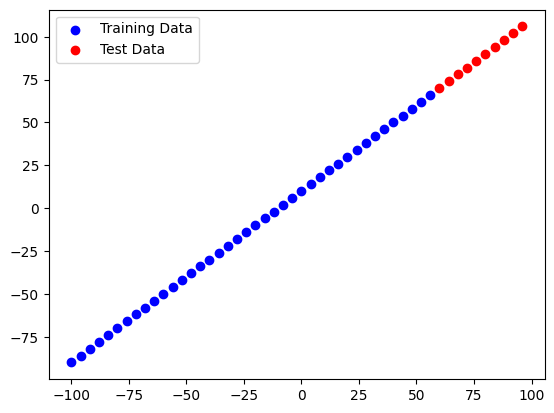

In [32]:
# Visualizing Training and Test Data:

plt.scatter(X_train, y_train, c= 'blue', label= 'Training Data')
plt.scatter(X_test, y_test, c= 'red', label= 'Test Data')
plt.legend()
plt.show()

#### Visualizing the model

After you've built a model, you might want to take a look at it (especially if you haven't built many before).

You can take a look at the layers and shapes of your model by calling [`summary()`](https://www.tensorflow.org/api_docs/python/tf/keras/Model#summary) on it.

> 🔑 **Note:** Visualizing a model is particularly helpful when you run into input and output shape mismatches.

In [33]:
# Building a Model:

tf.random.set_seed(42)
model= Sequential()
model.add(Dense(units= 1))
model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.1),
             loss= 'mae',
             metrics= ['mae'])

In [34]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

To get a Proper Model Summary, we either have to Fit the Model with some data, or we can provide "input_shape" in first layer of the Model.

In [35]:
# Building Same Model with "input_shape" argument in first Layer:

tf.random.set_seed(42)
model= Sequential()
model.add(Dense(units= 1, input_shape= [1,]))
model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.1),
             loss= 'mae',
             metrics= ['mae'])

In [36]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Calling `summary()` on our model shows us the layers it contains, the output shape and the number of parameters.
* **Total params** - total number of parameters in the model.
* **Trainable parameters** - these are the parameters (patterns) the model can update as it trains.
* **Non-trainable parameters** - these parameters aren't updated during training (this is typical when you bring in the already learned patterns from other models during transfer learning).

> 📖 **Resource:** For a more in-depth overview of the trainable parameters within a layer, check out [MIT's introduction to deep learning video](https://youtu.be/njKP3FqW3Sk).

In [37]:
# Training The Model:

model.fit(X_train, y_train, epochs= 100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 100.0371 - mae: 100.0371
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 91.4828 - mae: 91.4828
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 82.9434 - mae: 82.9434
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 74.4052 - mae: 74.4052
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 65.8672 - mae: 65.8672
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 57.3289 - mae: 57.3289
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 48.8517 - mae: 48.8517
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 40.4047 - mae: 40.4047
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 32.0328 - mae: 32.0328
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 23.8549 - mae: 23.8549
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 16.0453 - mae: 16.0453
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 9.8286 - mae: 9.8286  
Epoch 13/100
2/2 ━━━━━

#### Visualizing the predictions

To visualize predictions, it's always a good idea to plot them against the ground truth labels.

Often you'll see this in the form of `y_test` vs. `y_pred` (ground truth vs. predictions).

In [38]:
# Creating a Function to plot Training Data, Test Data and Predictions:

def plot_predictions(train_data,
                    train_labels,
                    test_data,
                    test_labels,
                    predictions):
    """
    Plots Training and Testing data With Predictions from Model.
    """

    plt.figure(figsize= (10,8))

    # Plotting Training Data:
    plt.scatter(train_data, train_labels, c= 'blue', label= 'Training Data')

    # Plotting Test Data:
    plt.scatter(test_data, test_labels, c= 'green', label= 'Testing Data')

    # Plotting Predictions:
    plt.scatter(test_data, predictions, c= 'red', label= 'Predictions')

    plt.legend()
    plt.show()

In [39]:
# Making Predictions using Trained Model:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


In [40]:
y_pred

array([[ 68.77873 ],
       [ 72.69516 ],
       [ 76.61159 ],
       [ 80.528015],
       [ 84.44444 ],
       [ 88.36087 ],
       [ 92.2773  ],
       [ 96.193726],
       [100.11015 ],
       [104.02658 ]], dtype=float32)

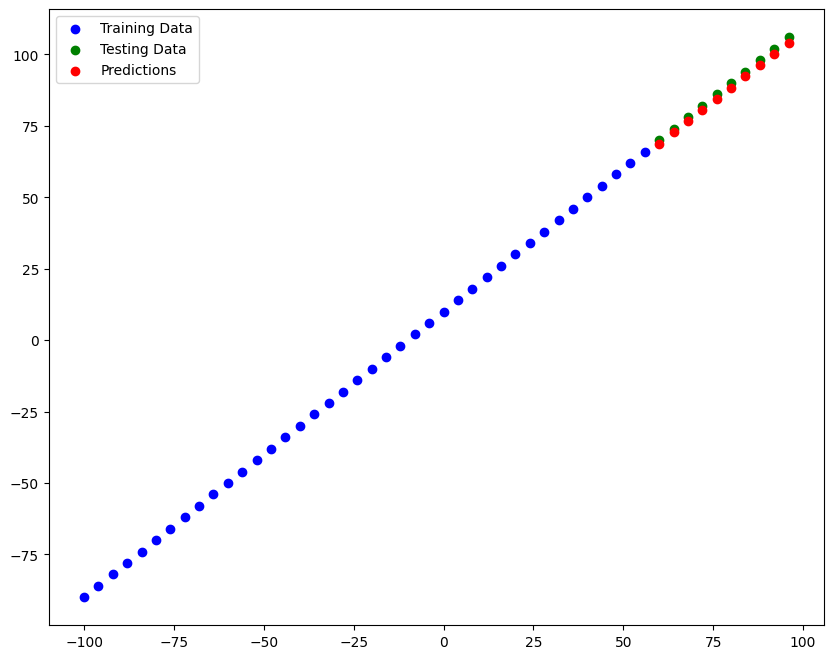

In [41]:
# Plotting:

plot_predictions(train_data= X_train,
                train_labels= y_train,
                test_data= X_test,
                test_labels= y_test,
                predictions= y_pred)

#### Evaluating predictions

Alongisde visualizations, evaulation metrics are your alternative best option for evaluating your model.

Depending on the problem we're working on, different models have different evaluation metrics. 

Two of the main metrics used for regression problems are:
* **Mean absolute error (MAE)** - the mean difference between each of the predictions.
* **Mean squared error (MSE)** - the squared mean difference between of the predictions (use if larger errors are more detrimental than smaller errors).

The lower each of these values, the better.

You can also use [`model.evaluate()`](https://www.tensorflow.org/api_docs/python/tf/keras/Model#evaluate) which will return the loss of the model as well as any metrics setup during the compile step.

In [42]:
model.evaluate(x= X_test,
              y= y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 1.5973 - mae: 1.5973


[1.5973434448242188, 1.5973434448242188]

In [43]:
# Mean Absolute Error:
mae= tf.metrics.mae(y_test, y_pred)
mae

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([1.2212677, 1.3048401, 1.3884125, 1.4719849, 1.5555573, 1.6391296,
       1.722702 , 1.8062744, 1.8898468, 1.9734192], dtype=float32)>

Huh? That's strange, MAE should be a single output.

Instead, we get 10 values.

This is because our `y_test` and `y_preds` tensors are different shapes.

In [44]:
print(y_test.shape, y_pred.shape)

(10,) (10, 1)


In [45]:
tf.squeeze(y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 68.77873 ,  72.69516 ,  76.61159 ,  80.528015,  84.44444 ,
        88.36087 ,  92.2773  ,  96.193726, 100.11015 , 104.02658 ],
      dtype=float32)>

In [46]:
mae= tf.metrics.mae(y_test, tf.squeeze(y_pred))
mae

<tf.Tensor: shape=(), dtype=float32, numpy=1.5973434448242188>

In [47]:
# Mean Squared Error:
mse= tf.metrics.mse(y_test, tf.squeeze(y_pred))
mse

<tf.Tensor: shape=(), dtype=float32, numpy=2.6091268062591553>

#### Running experiments to improve a model

After seeing the evaluation metrics and the predictions your model makes, it's likely you'll want to improve it.

Again, there are many different ways you can do this, but 3 of the main ones are:
1. **Get more data** - get more examples for your model to train on (more opportunities to learn patterns).
2. **Make your model larger (use a more complex model)** - this might come in the form of more layers or more hidden units in each layer.
3. **Train for longer** - give your model more of a chance to find the patterns in the data.

Since we created our dataset, we could easily make more data but this isn't always the case when you're working with real-world datasets.

So let's take a look at how we can improve our model using 2 and 3.

To do so, we'll build 3 models and compare their results:
1. `model_1` - same as original model, 1 layer, trained for 100 epochs.
2. `model_2` - 2 layers, trained for 100 epochs.
3. `model_3` - 2 layers, trained for 500 epochs.

``Model 1:``

In [49]:
tf.random.set_seed(42)

model_1 = Sequential()
model_1.add(Dense(units= 1, input_shape= [1, ]))
model_1.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.1),
               loss= 'mae',
               metrics= ['mae'])
model_1.fit(X_train, y_train, epochs= 100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 88.5172 - mae: 88.5172
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 79.9629 - mae: 79.9629
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 71.4234 - mae: 71.4234
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 62.8853 - mae: 62.8853
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 54.3473 - mae: 54.3473
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 45.8915 - mae: 45.8915
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 37.4446 - mae: 37.4446
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 29.1076 - mae: 29.1076
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 21.0413 - mae: 21.0413
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 13.3993 - mae: 13.3993
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8.8402 - mae: 8.8402
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 11.7544 - mae: 11.7544
Epoch 13/100
2/2 ━━━━━━━━━

In [50]:
#Predictions:
y_pred_1 = model_1.predict(X_test)
y_pred_1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([[ 67.965996],
       [ 71.829414],
       [ 75.69283 ],
       [ 79.55625 ],
       [ 83.41968 ],
       [ 87.2831  ],
       [ 91.146515],
       [ 95.00994 ],
       [ 98.87336 ],
       [102.73678 ]], dtype=float32)

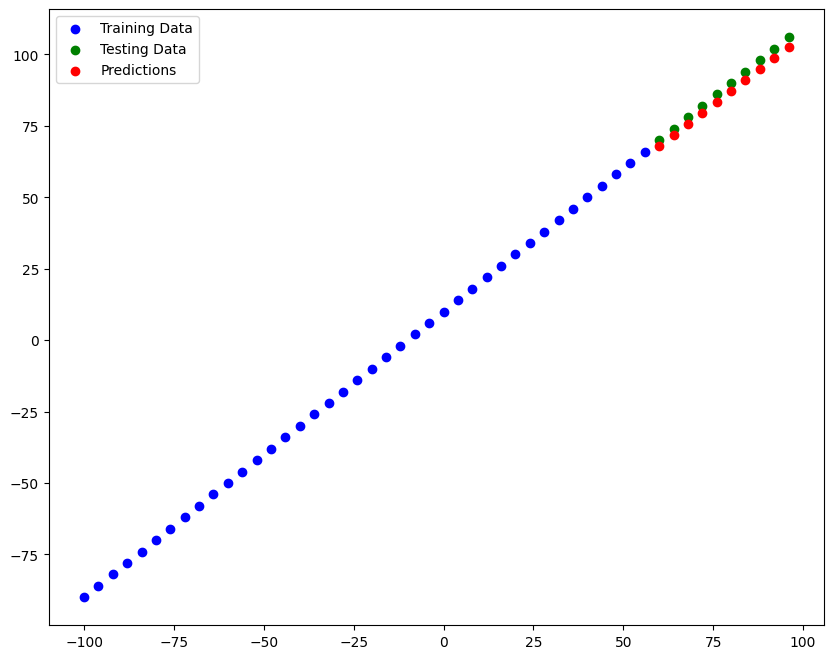

In [51]:
#Plotting Predictions:
plot_predictions(train_data= X_train,
                train_labels= y_train,
                test_data= X_test,
                test_labels= y_test,
                predictions= y_pred_1)

In [52]:
# MAE and MSE:
mae1 = tf.metrics.mae(y_test, tf.squeeze(y_pred_1))
mse1 = tf.metrics.mse(y_test, tf.squeeze(y_pred_1))

mae1, mse1

(<tf.Tensor: shape=(), dtype=float32, numpy=2.648613691329956>,
 <tf.Tensor: shape=(), dtype=float32, numpy=7.169049263000488>)

`Model 2:`

In [58]:
tf.random.set_seed(42)

model_2= Sequential()

model_2.add(Dense(units= 1, input_shape= [1, ]))
model_2.add(Dense(units= 1))

model_2.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.1),
               loss= 'mae',
               metrics= ['mae'])

model_2.fit(X_train, y_train, epochs= 100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - loss: 141.0979 - mae: 141.0979
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 116.5706 - mae: 116.5706
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 95.7675 - mae: 95.7675  
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 78.5846 - mae: 78.5846
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 64.9564 - mae: 64.9564
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 54.7542 - mae: 54.7542
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 47.7233 - mae: 47.7233
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 43.3873 - mae: 43.3873
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 41.2366 - mae: 41.2366
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 40.6872 - mae: 40.6872
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 41.1374 - mae: 41.1374
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 42.0356 - mae: 42.0356
Epoch 13/100
2/2 ━

In [59]:
# Predictions:
y_pred_2 = model_2.predict(X_test)
y_pred_2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


array([[ 70.645836],
       [ 74.68332 ],
       [ 78.720795],
       [ 82.75828 ],
       [ 86.79575 ],
       [ 90.83323 ],
       [ 94.87071 ],
       [ 98.90819 ],
       [102.94566 ],
       [106.98314 ]], dtype=float32)

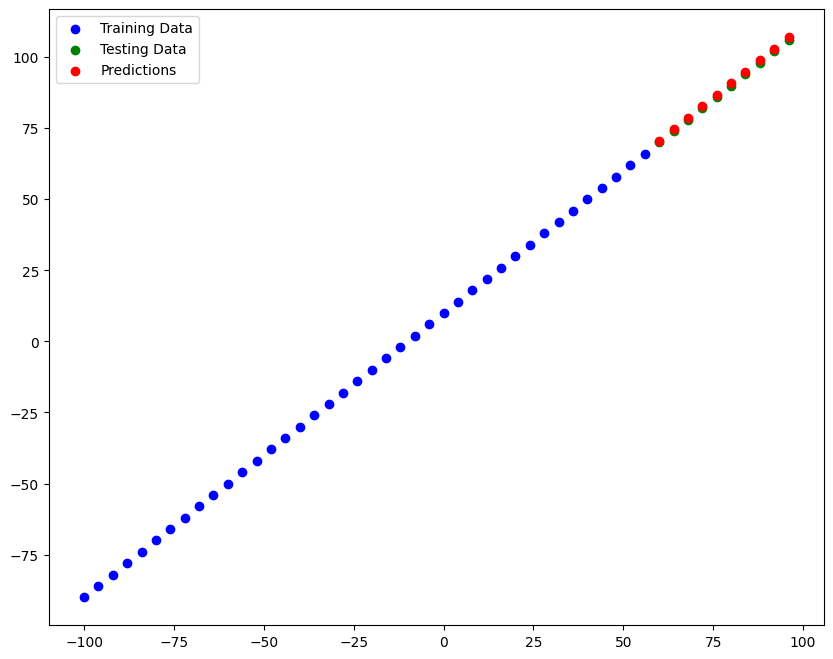

In [60]:
# Plotting Predictions:
plot_predictions(train_data= X_train,
                train_labels= y_train,
                test_data= X_test,
                test_labels= y_test,
                predictions= y_pred_2)

In [61]:
# MAE and MSE:
mae2 = tf.metrics.mae(y_test, tf.squeeze(y_pred_2))
mse2 = tf.metrics.mse(y_test, tf.squeeze(y_pred_2))

In [62]:
mae, mse

(<tf.Tensor: shape=(), dtype=float32, numpy=1.5973434448242188>,
 <tf.Tensor: shape=(), dtype=float32, numpy=2.6091268062591553>)

`Model 3:`

In [63]:
tf.random.set_seed(42)

model_3 = Sequential()

model_3.add(Dense(units= 10, input_shape= [1, ]))
model_3.add(Dense(units= 1))

model_3.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.1),
               loss= 'mae',
               metrics= ['mae'])

model_3.fit(X_train, y_train, epochs= 500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - loss: 12.3517 - mae: 12.3517
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 20.9090 - mae: 20.9090
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 17.2478 - mae: 17.2478
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 10.1909 - mae: 10.1909
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 10.2953 - mae: 10.2953
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 7.3785 - mae: 7.3785
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7.6501 - mae: 7.6501
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5.8088 - mae: 5.8088
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5.6844 - mae: 5.6844
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3.4156 - mae: 3.4156
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.9475 - mae: 2.9475
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.8706 - mae: 2.8706
Epoch 13/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 

In [64]:
# Predictions:
y_pred_3 = model_3.predict(X_test)
y_pred_3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


array([[ 66.62405 ],
       [ 70.41343 ],
       [ 74.20282 ],
       [ 77.992195],
       [ 81.78158 ],
       [ 85.57095 ],
       [ 89.36034 ],
       [ 93.14973 ],
       [ 96.93911 ],
       [100.72848 ]], dtype=float32)

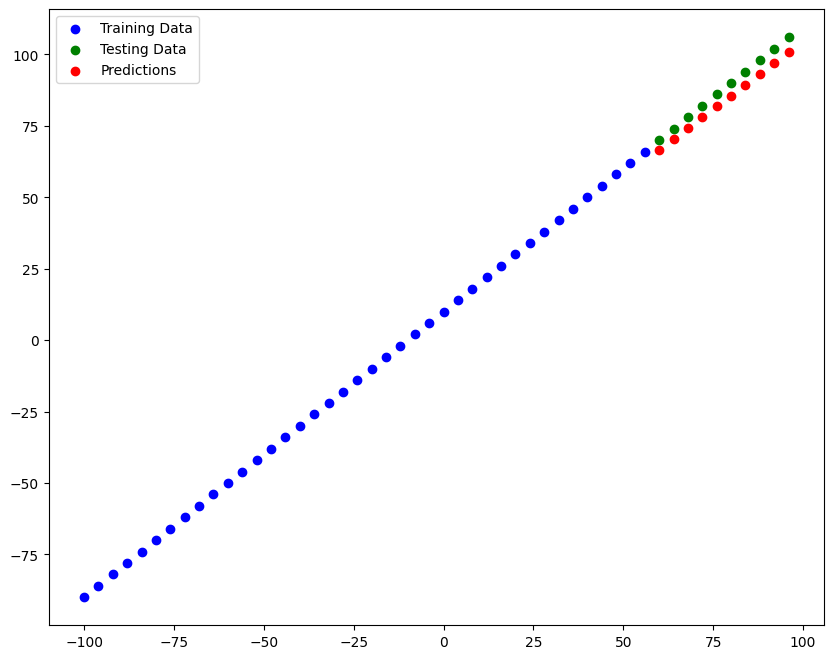

In [65]:
# Plotting Predictions:
plot_predictions(train_data= X_train,
                train_labels= y_train,
                test_data= X_test,
                test_labels= y_test,
                predictions= y_pred_3)

In [66]:
# MAE and MSE:
mae3 = tf.metrics.mae(y_test, tf.squeeze(y_pred_3))
mse3 = tf.metrics.mse(y_test, tf.squeeze(y_pred_3))

In [67]:
mae3, mse2

(<tf.Tensor: shape=(), dtype=float32, numpy=4.323732852935791>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.6749840974807739>)

#### Comparing results

Now we've got results for 3 similar but slightly different results, let's compare them.

In [68]:
model_results = [["model_1", mae1.numpy(), mse1.numpy()],
                 ["model_2", mae2.numpy(), mse2.numpy()],
                 ["model_3", mae3.numpy(), mse3.numpy()]]

In [69]:
import pandas as pd
results = pd.DataFrame(model_results, columns= ['Model Name',
                                               'Mean Absolute Error',
                                               'Mean Squared Error'])

In [70]:
results

,Model Name,Mean Absolute Error,Mean Squared Error
0,model_1,2.648614,7.169049
1,model_2,0.814491,0.674984
2,model_3,4.323733,19.060635


From our experiments, it looks like `model_2` performed the best.

And now, you might be thinking, "wow, comparing models is tedious..." and it definitely can be, we've only compared 3 models here. 

But this is part of what machine learning modelling is about, trying many different combinations of models and seeing which performs best.

Each model you build is a small experiment. 

> 🔑 **Note:** One of your main goals should be to minimize the time between your experiments. The more experiments you do, the more things you'll figure out which don't work and in turn, get closer to figuring out what does work.

Another thing you'll also find is what you thought may work (such as training a model for longer) may not always work and the exact opposite is also often the case.

## Tracking your experiments

One really good habit to get into is tracking your modelling experiments to see which perform better than others.

We've done a simple version of this above (keeping the results in different variables).

> 📖 **Resource:** But as you build more models, you'll want to look into using tools such as:
* [**TensorBoard**](https://www.tensorflow.org/tensorboard) - a component of the TensorFlow library to help track modelling experiments.
* [**Weights & Biases**](https://www.wandb.com/) - a tool for tracking all kinds of machine learning experiments (the good news for Weights & Biases is it plugs into TensorBoard).

#### Saving a model

Once you've trained a model and found one which performs to your liking, you'll probably want to save it for use elsewhere (like a web application or mobile device).

You can save a TensorFlow/Keras model using [`model.save()`](https://www.tensorflow.org/tutorials/keras/save_and_load#save_the_entire_model).

There are two ways to save a model in TensorFlow:
1. The [SavedModel format](https://www.tensorflow.org/tutorials/keras/save_and_load#savedmodel_format) (default).
2. The [HDF5 format](https://www.tensorflow.org/tutorials/keras/save_and_load#hdf5_format).

The main difference between the two is the SavedModel is automatically able to save custom objects (such as special layers) without additional modifications when loading the model back in.

Which one should you use?

It depends on your situation but the SavedModel format will suffice most of the time.

Both methods use the same method call.

In [71]:
model_2.save('Regression_Model(Random Data).keras')

In [72]:
model_2.save('Regression_Model(Random Data).h5')

#### Loading a model

We can load a saved model using the [`load_model()`](https://www.tensorflow.org/api_docs/python/tf/keras/models/load_model) method.

Loading a model for the different formats (SavedModel and HDF5) is the same (as long as the pathnames to the particuluar formats are correct).

In [73]:
loaded_model1 = tf.keras.models.load_model('Regression_Model(Random Data).keras')

In [74]:
loaded_model1.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (60.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10 (44.00 B)

In [75]:
model_2.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (60.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10 (44.00 B)

# A Larger Example:

We're going to try predict the cost of medical insurance for individuals based on a number of different parameters such as, `age`, `sex`, `bmi`, `children`, `smoking_status` and `residential_region`.

To do, we'll leverage the pubically available [Medical Cost dataset](https://www.kaggle.com/mirichoi0218/insurance) available from Kaggle and [hosted on GitHub](https://github.com/stedy/Machine-Learning-with-R-datasets/blob/master/insurance.csv).

In [76]:
# Importing Required libraries:

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split

In [78]:
df= pd.read_csv('insurance.csv')

In [79]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


We're going to have to turn the non-numerical columns into numbers (because a neural network can't handle non-numerical inputs).

To do so, we'll use the [`get_dummies()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html) method in pandas.

It converts categorical variables (like the `sex`, `smoker` and `region` columns) into numerical variables using one-hot encoding.

In [82]:
# Turning Categorical Columns into Numerical Using One Hot Encoding:

df_one_hot = pd.get_dummies(df)
df_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [84]:
# Creating Features and Target:

X = df_one_hot.drop('charges', axis= 1)
y = df_one_hot['charges']

In [85]:
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False


In [86]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [87]:
# Train Test Split:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size= 0.2, 
                                                    random_state= 42)

In [88]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 11)
(268, 11)
(1070,)
(268,)


In [89]:
# Building a Neural Network:

tf.random.set_seed(42)

reg_model1 = Sequential()

reg_model1.add(Dense(units= 10))
reg_model1.add(Dense(units= 1))

reg_model1.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.01),
                  loss= 'mae',
                  metrics= ['mae'])

reg_model1.fit(X_train, y_train, epochs= 100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 13315.2236 - mae: 13315.2236
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13098.7744 - mae: 13098.7744
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12545.7607 - mae: 12545.7607
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11512.2500 - mae: 11512.2500
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10133.5205 - mae: 10133.5205
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8805.9131 - mae: 8805.9131
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7880.6636 - mae: 7880.6636
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7519.6064 - mae: 7519.6064
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7446.2065 - mae: 7446.2065
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7418.0625 - mae: 7418.0625
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7396.2773 - mae: 7396.2773
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0

In [90]:
# Evaluating Model:
reg_model1.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 5243.3823 - mae: 5243.3823


[5243.38232421875, 5243.38232421875]

In [91]:
df['charges'].mean()

13270.422265141257

Our model didn't perform very well, let's try a bigger model.

We'll try 3 things:
- Increasing the number of layers (2 -> 3).
- Increasing the number of units in each layer (except for the output layer).
- Train for Longer Time (More Epochs).
Everything else will stay the same.

In [92]:
# Building Another Neural Network:

tf.random.set_seed(42)

reg_model2= Sequential()

reg_model2.add(Dense(units= 100))
reg_model2.add(Dense(units= 10))
reg_model2.add(Dense(units= 1))

reg_model2.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.01),
                  loss= 'mae',
                  metrics= ['mae'])

history= reg_model2.fit(X_train, y_train, epochs= 200)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 11618.8184 - mae: 11618.8184
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7536.9849 - mae: 7536.9849
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7254.9458 - mae: 7254.9458
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7047.1030 - mae: 7047.1030
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6782.1792 - mae: 6782.1792
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6522.1968 - mae: 6522.1968
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6357.9473 - mae: 6357.9473
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6224.4619 - mae: 6224.4619
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6069.6279 - mae: 6069.6279
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5870.1021 - mae: 5870.1021
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5599.3457 - mae: 5599.3457
Epoch 12/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/st

In [93]:
# Evaluating The Model:
reg_model2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 3157.0383 - mae: 3157.0383


[3157.038330078125, 3157.038330078125]

In [94]:
df['charges'].mean()

13270.422265141257

In [95]:
# Plotting History or Loss Curve:
history.history.keys()

dict_keys(['loss', 'mae'])

<Axes: >

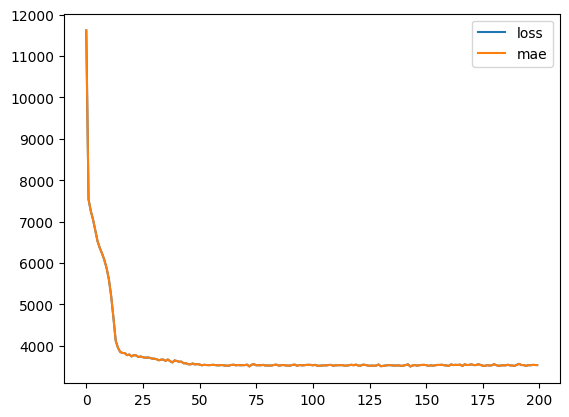

In [96]:
pd.DataFrame(history.history).plot()

> **Question:** How long should you train for? 

> It depends on what problem you're working on. Sometimes training won't take very long, other times it'll take longer than you expect. A common method is to set your model training for a very long time (e.g. 1000's of epochs) but set it up with an [EarlyStopping callback](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping) so it stops automatically when it stops improving. We'll see this in another module.